In [21]:
# 6 strategies, used StraightForceToColony to see if results are different

# adding ApplyColonyPullingForce() to informed as 5 but more runs
# run on maze more time than 7 200 ants detchafter 4f to 10f 	float colonyPullStrength = 4.0f

#changes strategies 0  is always on 
#checking wich combination is the best
# Map 4 
# x3 amount of pheromones   public float dstBetweenMarkers = 0.75f; - > 0.2f

In [22]:
from sim_tools import run_simulation, SimulationParameters, run_simulations_batch, load_results_from_directory, SimulationData
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [23]:
num_sim = 50
steering_strategies = 6

In [24]:
batch_results = load_results_from_directory("sim16_results")
print(f"Loaded {len(batch_results)} simulation results.")

Loaded 1816 simulation results.


In [25]:

# batch = [
#     SimulationParameters(usePheromoneSteering=i % steering_strategies)
#     for i in range(steering_strategies * num_sim)
# ]
# batch_results = run_simulations_batch(batch)
# batch_results = zip(batch, batch_results)

In [26]:
Steering_names = [
    "home",
    "circle",
    "gradient",
    "gaussian",
    "Inverse Square",
    "Exponential",
]

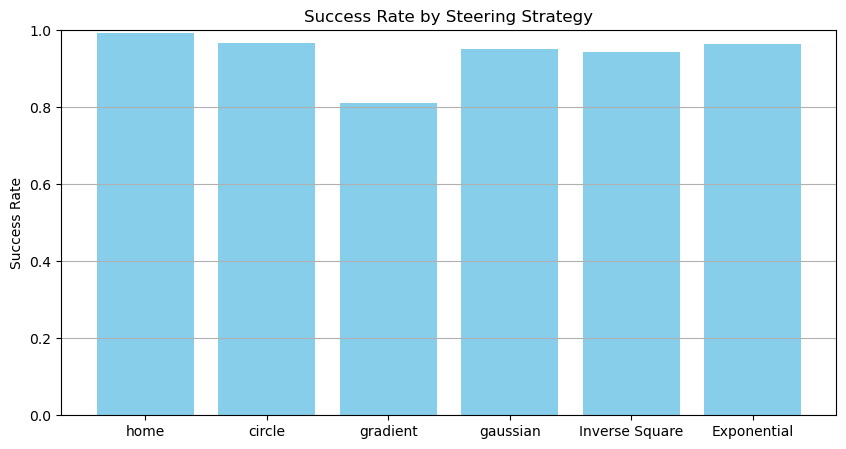

home: Success Rate=99.34% (302/304)
circle: Success Rate=96.69% (292/302)
gradient: Success Rate=81.13% (245/302)
gaussian: Success Rate=95.05% (288/303)
Inverse Square: Success Rate=94.37% (285/302)
Exponential: Success Rate=96.37% (292/303)


In [27]:
def plot_success_rates(batch_results: list[SimulationData], num_strategies=6, strategy_names=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), success_rates,
            tick_label=labels, color='skyblue')
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")



plot_success_rates(batch_results, steering_strategies, Steering_names)

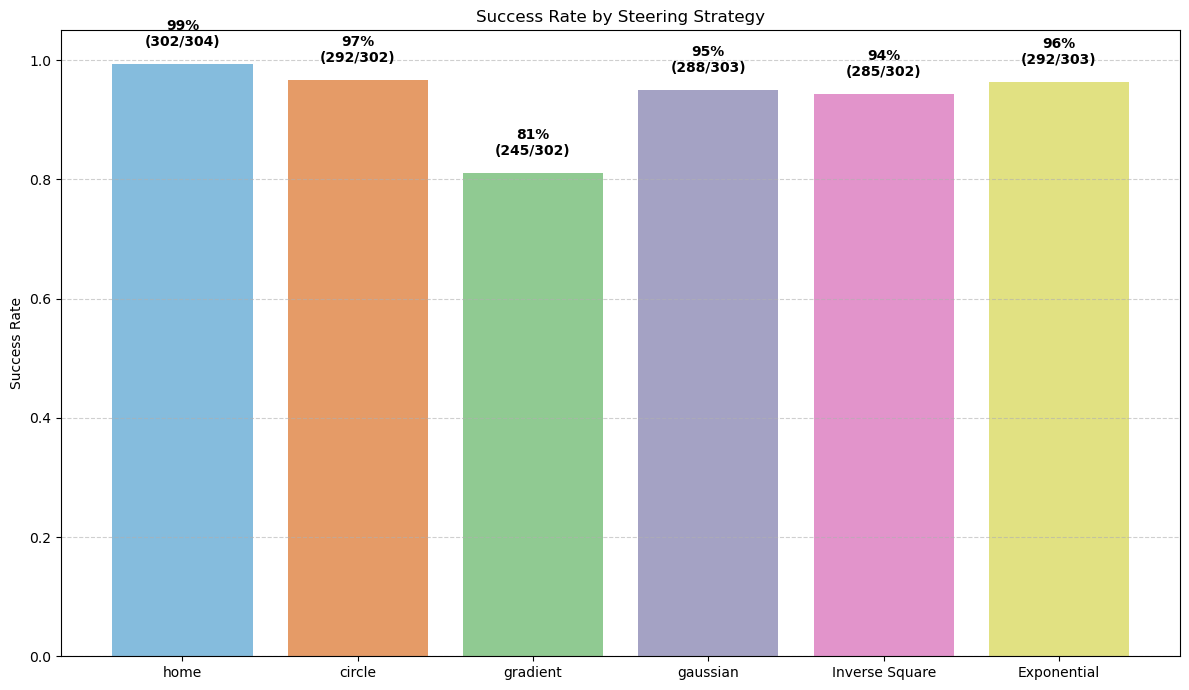

home: Success Rate=99.34% (302/304)
circle: Success Rate=96.69% (292/302)
gradient: Success Rate=81.13% (245/302)
gaussian: Success Rate=95.05% (288/303)
Inverse Square: Success Rate=94.37% (285/302)
Exponential: Success Rate=96.37% (292/303)


In [28]:
def plot_success_rates(batch_results: list, num_strategies=6, strategy_names=None, summary_text=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Bar colors for visual interest
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(num_strategies), success_rates,
                   tick_label=labels, color=colors)
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1.05)  # Just a little space above bars

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate bars with percentage and counts
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.025,
                 f"{success_rates[i]*100:.0f}%\n({success_counts[i]}/{total_counts[i]})",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust()  # Make space at the bottom
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


# Example usage:
summary = (
    "home: Success Rate=60.00% (30/50)\n"
    "circle: Success Rate=92.00% (46/50)\n"
    "gradient: Success Rate=84.00% (42/50)\n"
    "gaussian: Success Rate=94.00% (47/50)\n"
    "Inverse Square: Success Rate=96.00% (48/50)\n"
    "Exponential: Success Rate=86.00% (43/50)"
)
plot_success_rates(batch_results, steering_strategies, Steering_names, )

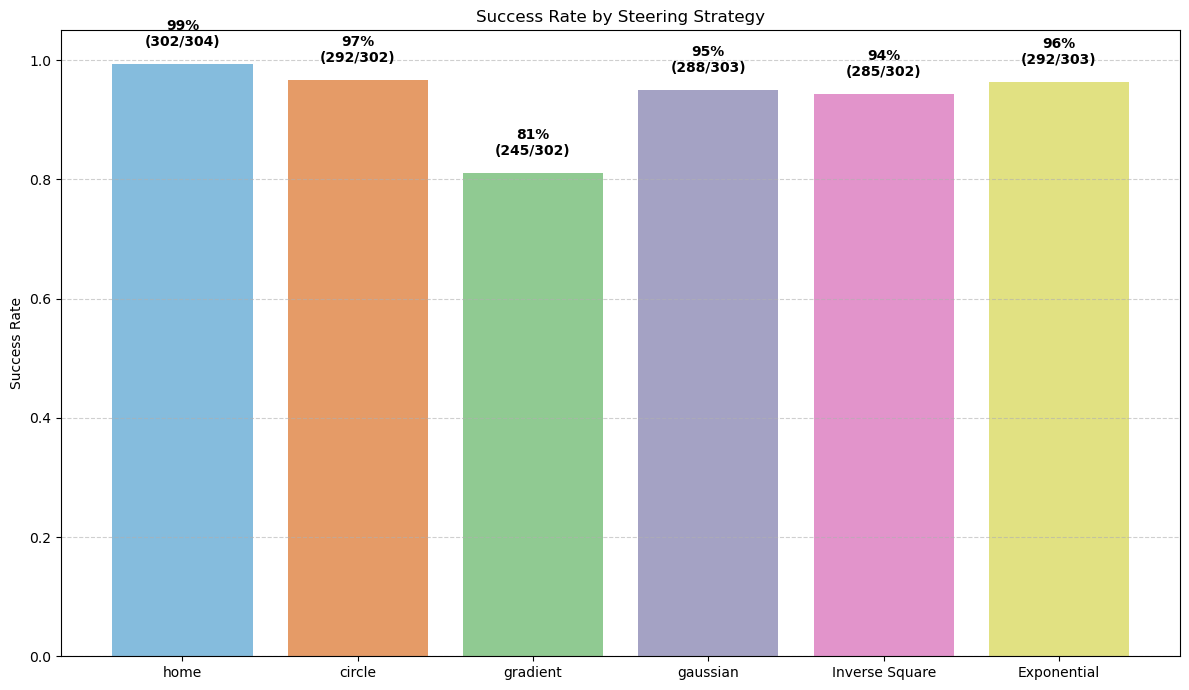

home: Success Rate=99.34% (302/304)
circle: Success Rate=96.69% (292/302)
gradient: Success Rate=81.13% (245/302)
gaussian: Success Rate=95.05% (288/303)
Inverse Square: Success Rate=94.37% (285/302)
Exponential: Success Rate=96.37% (292/303)


In [29]:
def plot_success_rates(batch_results: list, num_strategies=6, strategy_names=None, summary_text=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Bar colors for visual interest
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(num_strategies), success_rates,
                   tick_label=labels, color=colors)
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1.05)  # Just a little space above bars

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate bars with percentage and counts
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.025,
                 f"{success_rates[i]*100:.0f}%\n({success_counts[i]}/{total_counts[i]})",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust()  # Make space at the bottom
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


# Example usage:
summary = (
    "home: Success Rate=60.00% (30/50)\n"
    "circle: Success Rate=92.00% (46/50)\n"
    "gradient: Success Rate=84.00% (42/50)\n"
    "gaussian: Success Rate=94.00% (47/50)\n"
    "Inverse Square: Success Rate=96.00% (48/50)\n"
    "Exponential: Success Rate=86.00% (43/50)"
)
plot_success_rates(batch_results, steering_strategies, Steering_names, )

In [30]:
print("Batch results:", len(batch_results))
len(batch_results)

Batch results: 1816


1816

In [31]:
# print results
def print_results(batch_results):
    for res, ss in batch_results:
        if res:
            print(
                f"Run (usePheromoneSteering={ss}): Success, duration={res.duration}, success={res.didSucceed}")
        else:
            print(f"Run (usePheromoneSteering={ss}): Failed")                      

In [32]:
import matplotlib.pyplot as plt


def plot_torus_positions_by_strategy(batch_results, strategy_names=None):
    """
    Plots the torus positions for each strategy in separate graphs.
    Each plot shows the paths for all successful runs of that strategy.
    """
    if strategy_names is None:
        strategy_names = [f"Steering={i}" for i in range(steering_strategies)]

    for strategy in range(steering_strategies):
        # Collect all successful torus positions for this strategy
        paths = [
            res.torusPositions for params, res in batch_results
            if params.usePheromoneSteering == strategy and res  and res.didSucceed
        ]
        if not paths:
            continue  # Skip if no successful runs

        plt.figure(figsize=(6, 6))
        for path in paths:
            xs = [p.x for p in path]
            ys = [p.y for p in path]
            plt.plot(xs, ys, alpha=0.5)
        plt.title(f"Torus Paths - {strategy_names[strategy]}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

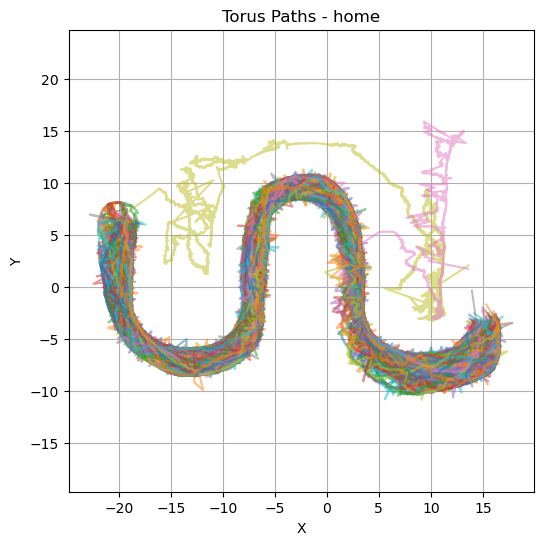

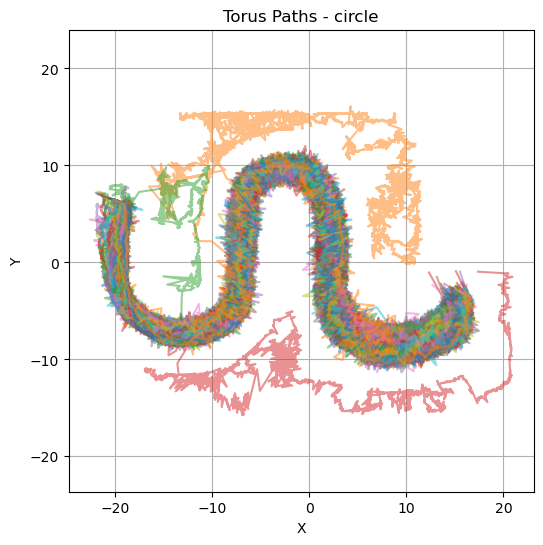

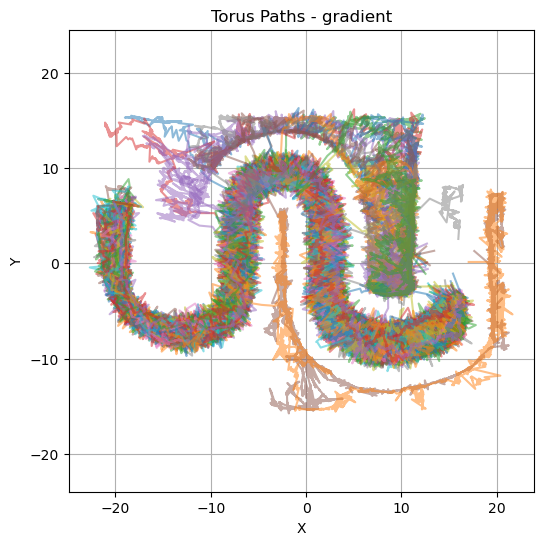

In [ ]:
plot_torus_positions_by_strategy(batch_results, Steering_names)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_duration_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """

    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and res.didSucceed:
            durations_by_strategy[params.usePheromoneSteering].append(res.duration)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(steering_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(durations_by_strategy, tick_labels=labels)
    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average duration for each strategy
    for i in range(steering_strategies):
        avg = np.mean(
            durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")

# Example usage:

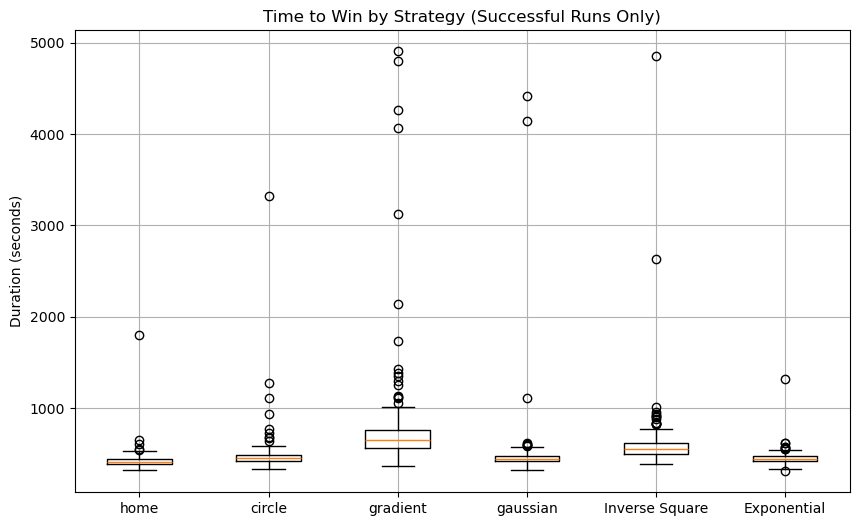

home: Average Duration = 421.56 seconds
circle: Average Duration = 474.17 seconds
gradient: Average Duration = 752.98 seconds
gaussian: Average Duration = 478.82 seconds
Inverse Square: Average Duration = 592.83 seconds
Exponential: Average Duration = 452.33 seconds


In [ ]:
plot_duration_comparison(batch_results, Steering_names)

In [ ]:

def plot_smoothness_comparison(batch_results, strategy_names=None, summary_text=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    smoothness_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[params.usePheromoneSteering].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float('nan')
        for i in range(steering_strategies)
    ]

    # Prepare labels and colors
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(strategy_names) else f"Steering={i}" for i in range(steering_strategies)]
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    # Plot
    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(steering_strategies), mean_smoothness,
                   tick_label=labels, color=colors, alpha=0.85)
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.ylim(bottom=0)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate with average turning angle in black, above each bar at the same relative position
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05*(plt.ylim()[1] - plt.ylim()[0]),
                 f"{height:.1f}°", ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust(bottom=0.25)
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='bottom', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(steering_strategies):
        print(f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")

# Example usage:
smoothness_summary = (
    "home: Average Turning Angle = 12.3°\n"
    "circle: Average Turning Angle = 9.8°\n"
    "gradient: Average Turning Angle = 10.5°\n"
    "gaussian: Average Turning Angle = 8.7°\n"
    "Inverse Square: Average Turning Angle = 15.2°\n"
    "Exponential: Average Turning Angle = 13.6°"
)
plot_smoothness_comparison(batch_results, Steering_names, smoothness_summary)


NameError: name 'compute_average_turning_angle' is not defined

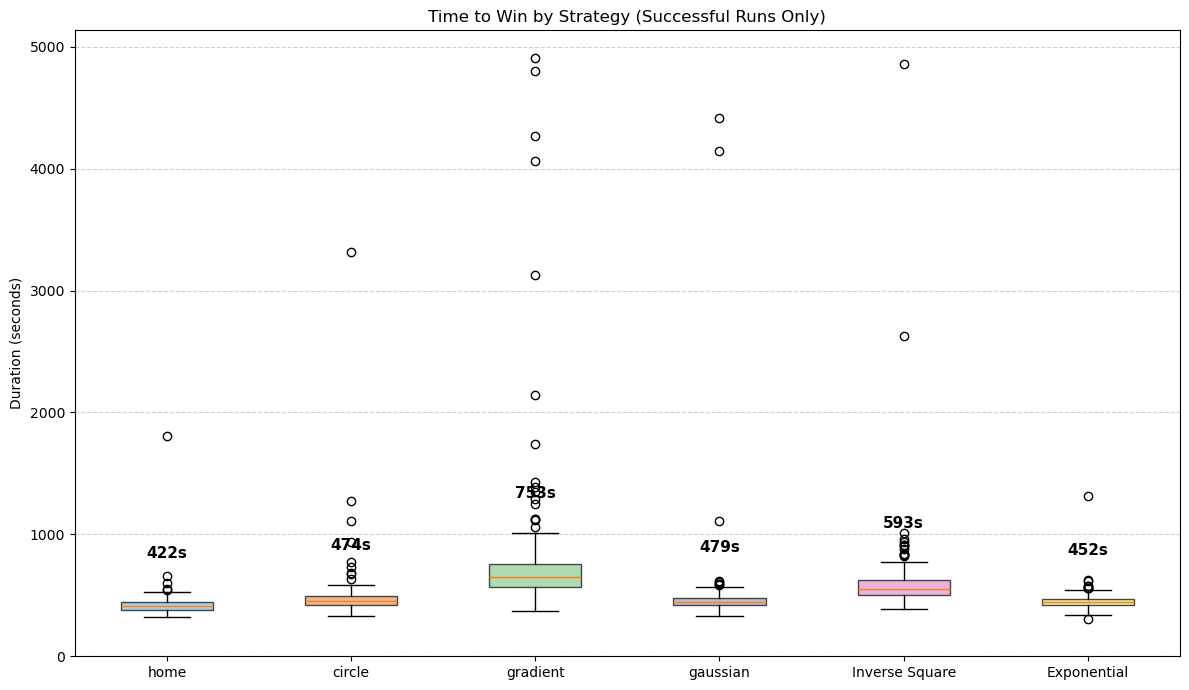

home: Average Duration = 421.56 seconds
circle: Average Duration = 474.17 seconds
gradient: Average Duration = 752.98 seconds
gaussian: Average Duration = 478.82 seconds
Inverse Square: Average Duration = 592.83 seconds
Exponential: Average Duration = 452.33 seconds


In [ ]:

def plot_duration_comparison(batch_results, strategy_names=None, summary_text=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """
    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and res.didSucceed:
            durations_by_strategy[params.usePheromoneSteering].append(res.duration)

    # Prepare labels and colors
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(strategy_names) else f"Steering={i}" for i in range(steering_strategies)]
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    # Plot boxplot with colored boxes
    plt.figure(figsize=(12, 7))
    box = plt.boxplot(durations_by_strategy, patch_artist=True, tick_labels=labels)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.ylim(bottom=0)

    # Annotate with average duration in black, above each box at the same relative position
    for i, data in enumerate(durations_by_strategy):
        if data:
            avg = np.mean(data)
            # Get the box's top y-value (whisker or box)
            y_max = max(box['whiskers'][2*i].get_ydata().max(), box['whiskers'][2*i+1].get_ydata().max())
            plt.text(i+1, y_max + 0.05*(plt.ylim()[1] - plt.ylim()[0]), f"{avg:.0f}s",
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust(bottom=0.25)
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='bottom', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print average duration for each strategy
    for i in range(steering_strategies):
        avg = np.mean(durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")


# Example usage:
summary = (
    "home: Average Duration = 434.14 seconds\n"
    "circle: Average Duration = 343.32 seconds\n"
    "gradient: Average Duration = 363.62 seconds\n"
    "gaussian: Average Duration = 319.42 seconds\n"
    "Inverse Square: Average Duration = 565.17 seconds\n"
    "Exponential: Average Duration = 471.49 seconds"
)
plot_duration_comparison(batch_results, Steering_names, )

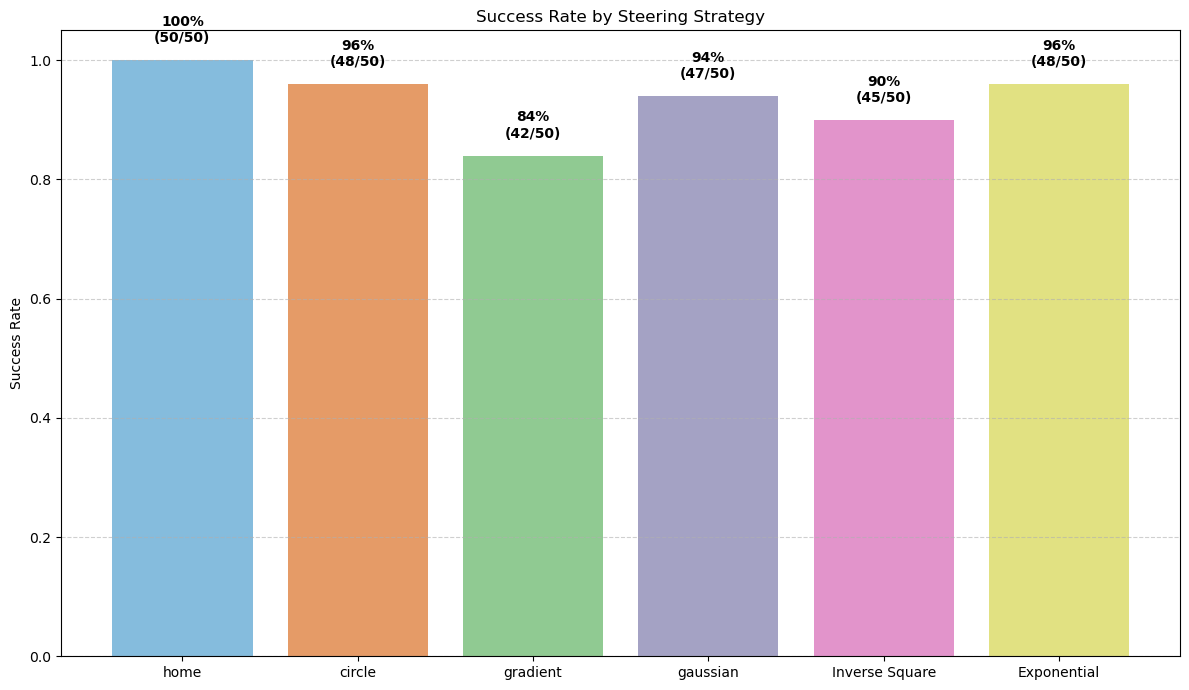

home: Success Rate=100.00% (50/50)
circle: Success Rate=96.00% (48/50)
gradient: Success Rate=84.00% (42/50)
gaussian: Success Rate=94.00% (47/50)
Inverse Square: Success Rate=90.00% (45/50)
Exponential: Success Rate=96.00% (48/50)


In [ ]:
def plot_success_rates(batch_results: list, num_strategies=6, strategy_names=None, summary_text=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Bar colors for visual interest
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(num_strategies), success_rates,
                   tick_label=labels, color=colors)
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1.05)  # Just a little space above bars

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate bars with percentage and counts
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.025,
                 f"{success_rates[i]*100:.0f}%\n({success_counts[i]}/{total_counts[i]})",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust()  # Make space at the bottom
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


# Example usage:
summary = (
    "home: Success Rate=60.00% (30/50)\n"
    "circle: Success Rate=92.00% (46/50)\n"
    "gradient: Success Rate=84.00% (42/50)\n"
    "gaussian: Success Rate=94.00% (47/50)\n"
    "Inverse Square: Success Rate=96.00% (48/50)\n"
    "Exponential: Success Rate=86.00% (43/50)"
)
plot_success_rates(batch_results, steering_strategies, Steering_names, )

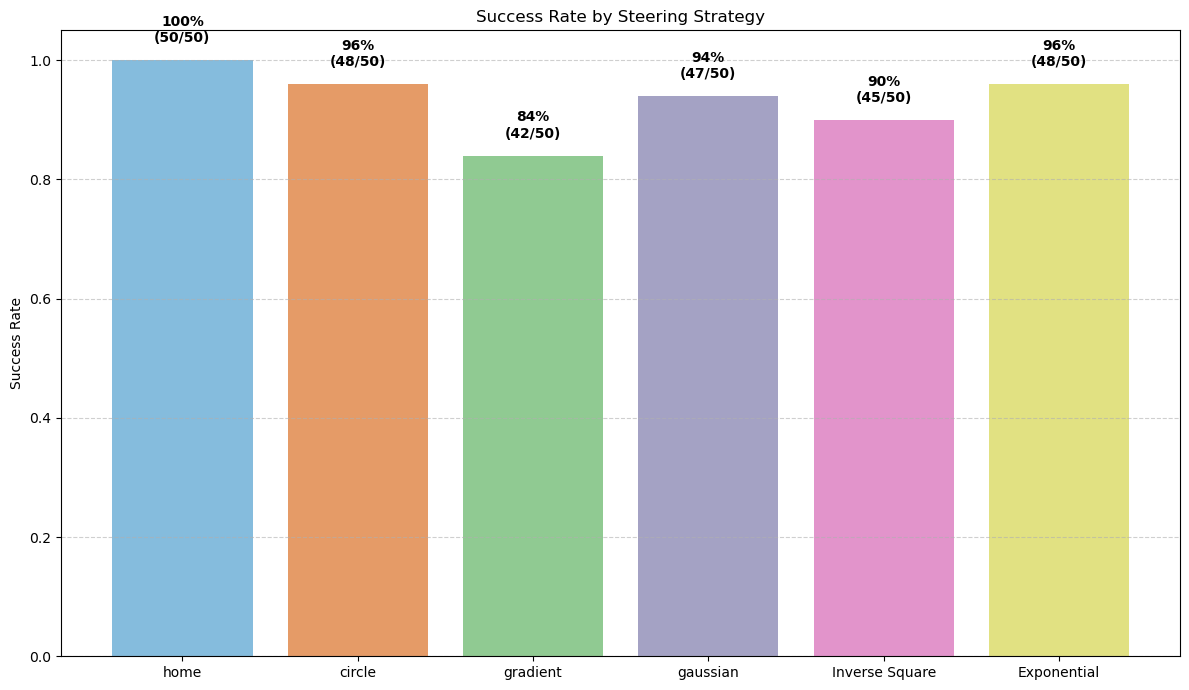

home: Success Rate=100.00% (50/50)
circle: Success Rate=96.00% (48/50)
gradient: Success Rate=84.00% (42/50)
gaussian: Success Rate=94.00% (47/50)
Inverse Square: Success Rate=90.00% (45/50)
Exponential: Success Rate=96.00% (48/50)


In [ ]:
def plot_success_rates(batch_results: list, num_strategies=6, strategy_names=None, summary_text=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Bar colors for visual interest
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(num_strategies), success_rates,
                   tick_label=labels, color=colors)
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1.05)  # Just a little space above bars

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate bars with percentage and counts
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.025,
                 f"{success_rates[i]*100:.0f}%\n({success_counts[i]}/{total_counts[i]})",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust()  # Make space at the bottom
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


# Example usage:
summary = (
    "home: Success Rate=60.00% (30/50)\n"
    "circle: Success Rate=92.00% (46/50)\n"
    "gradient: Success Rate=84.00% (42/50)\n"
    "gaussian: Success Rate=94.00% (47/50)\n"
    "Inverse Square: Success Rate=96.00% (48/50)\n"
    "Exponential: Success Rate=86.00% (43/50)"
)
plot_success_rates(batch_results, steering_strategies, Steering_names, )

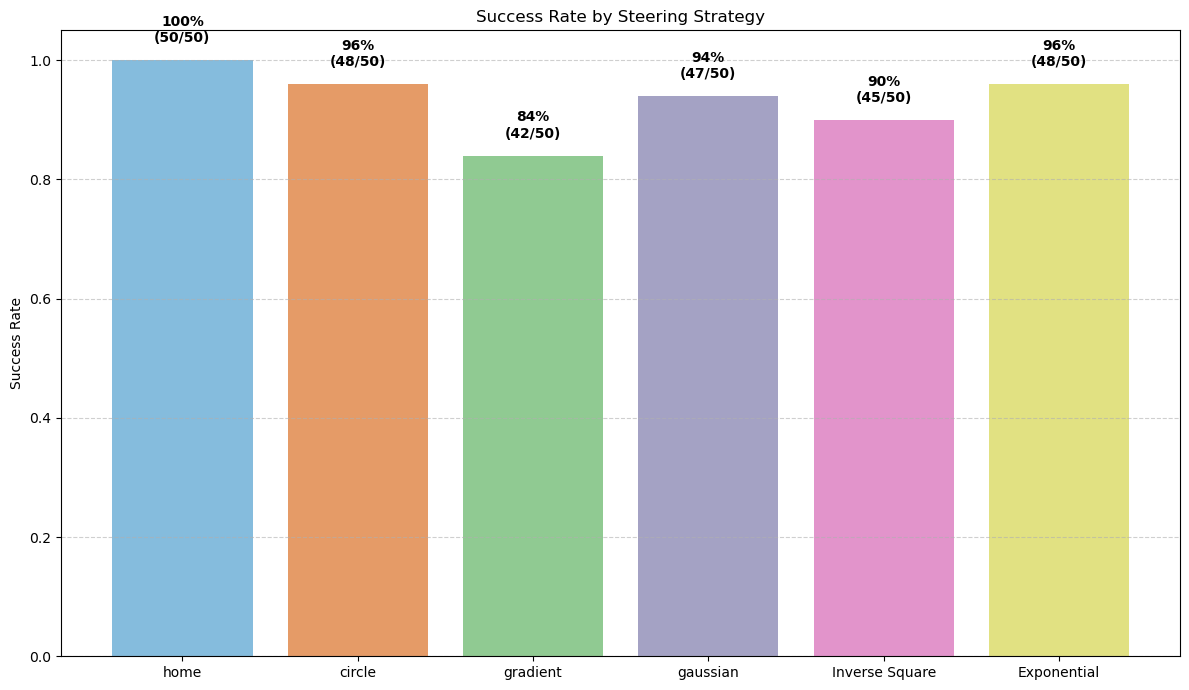

home: Success Rate=100.00% (50/50)
circle: Success Rate=96.00% (48/50)
gradient: Success Rate=84.00% (42/50)
gaussian: Success Rate=94.00% (47/50)
Inverse Square: Success Rate=90.00% (45/50)
Exponential: Success Rate=96.00% (48/50)


In [ ]:
def plot_success_rates(batch_results: list, num_strategies=6, strategy_names=None, summary_text=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Bar colors for visual interest
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(num_strategies), success_rates,
                   tick_label=labels, color=colors)
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1.05)  # Just a little space above bars

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate bars with percentage and counts
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.025,
                 f"{success_rates[i]*100:.0f}%\n({success_counts[i]}/{total_counts[i]})",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust()  # Make space at the bottom
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='center', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


# Example usage:
summary = (
    "home: Success Rate=60.00% (30/50)\n"
    "circle: Success Rate=92.00% (46/50)\n"
    "gradient: Success Rate=84.00% (42/50)\n"
    "gaussian: Success Rate=94.00% (47/50)\n"
    "Inverse Square: Success Rate=96.00% (48/50)\n"
    "Exponential: Success Rate=86.00% (43/50)"
)
plot_success_rates(batch_results, steering_strategies, Steering_names, )

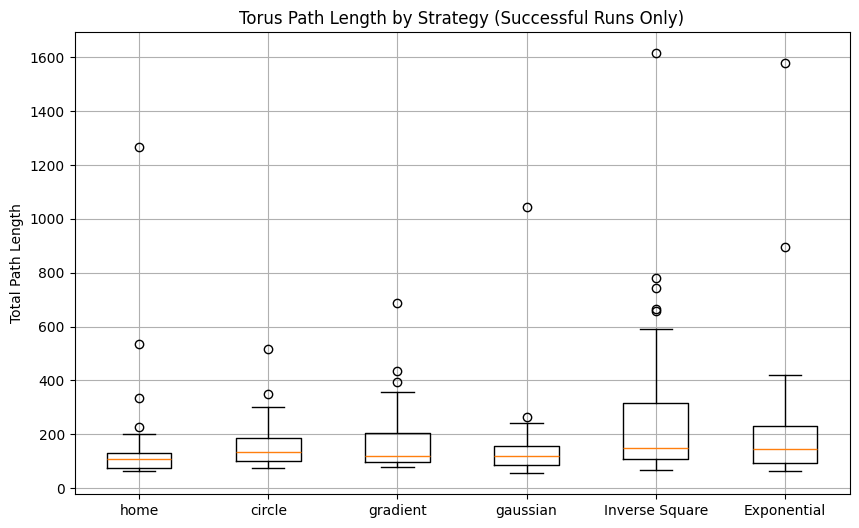

home: Average Path Length = 169.18
circle: Average Path Length = 157.09
gradient: Average Path Length = 172.38
gaussian: Average Path Length = 144.46
Inverse Square: Average Path Length = 266.04
Exponential: Average Path Length = 220.91


In [ ]:
plot_path_length_comparison(batch_results, Steering_names)

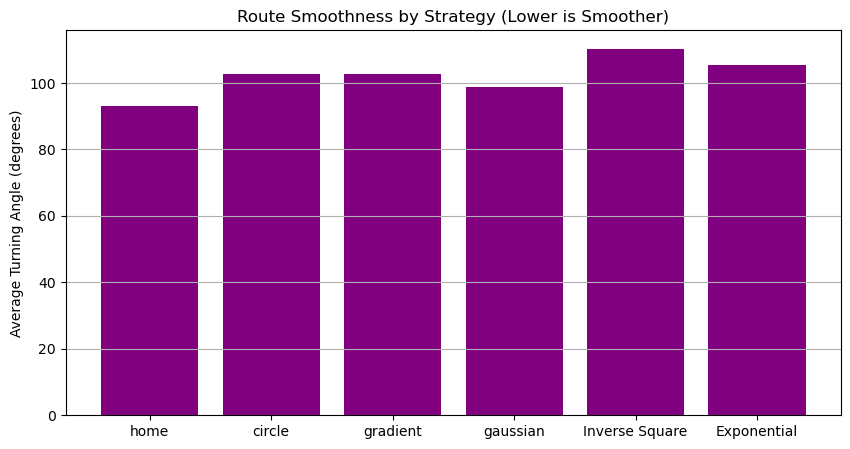

home: Average Turning Angle = 93.02°
circle: Average Turning Angle = 102.67°
gradient: Average Turning Angle = 102.73°
gaussian: Average Turning Angle = 98.71°
Inverse Square: Average Turning Angle = 110.35°
Exponential: Average Turning Angle = 105.31°


C:\Users\mayai\AppData\Local\Temp\ipykernel_37128\802766198.py:103: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


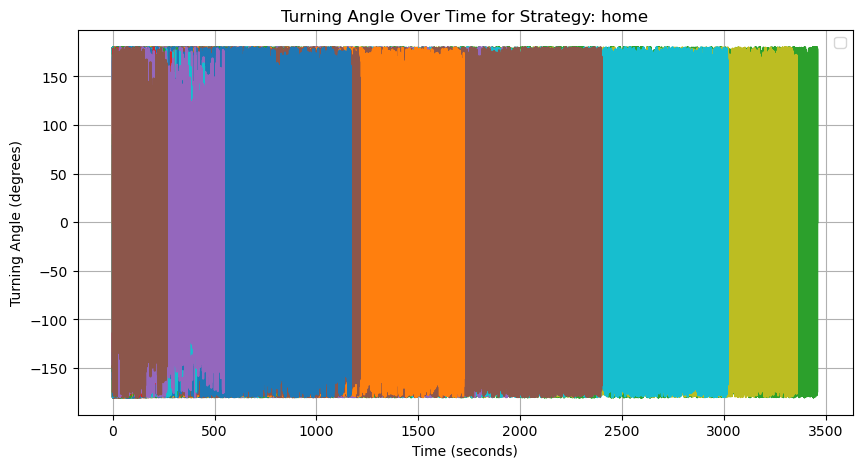

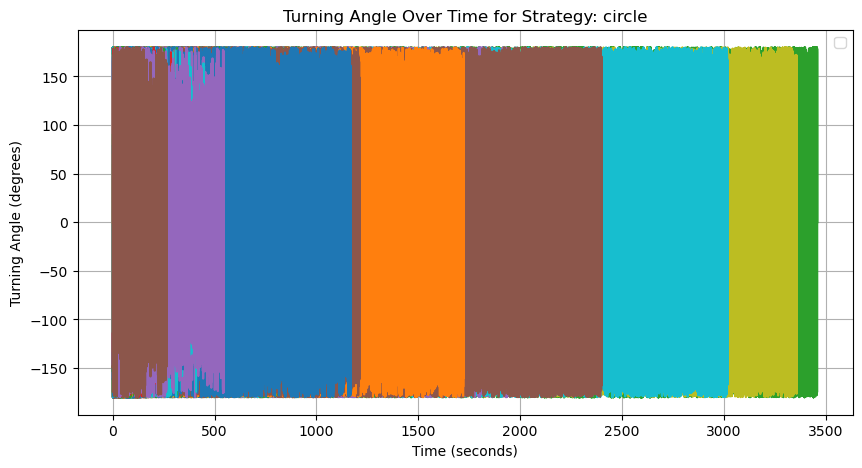

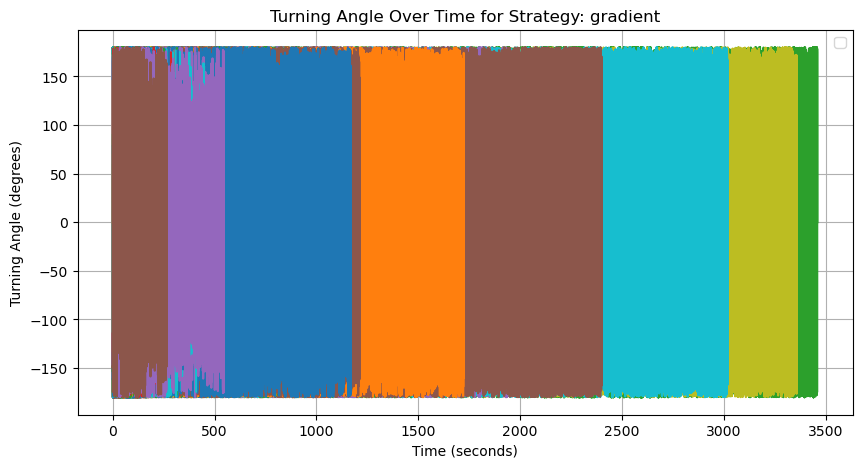

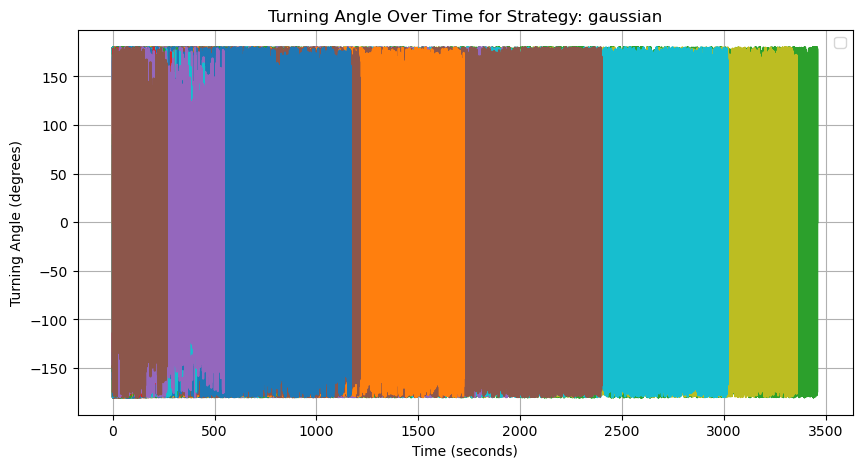

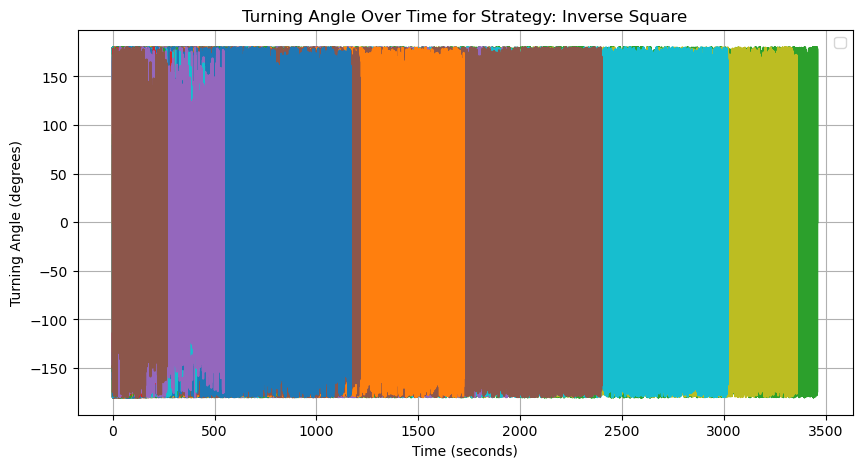

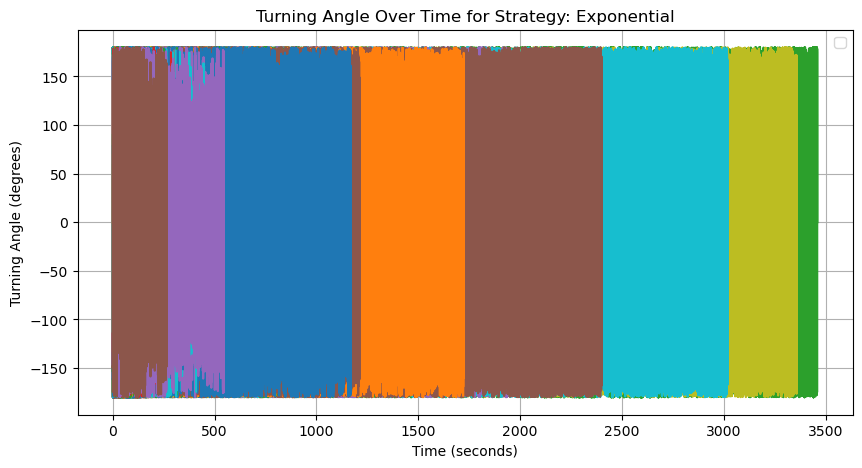

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def compute_turning_angles(points):
    """Compute average signed turning angle (in degrees) between consecutive segments of a path."""
    if len(points) < 3:
        return 0.0

    # Extract coordinates as arrays
    coords = np.array([[p.x, p.y] for p in points])

    # Compute vectors between consecutive points
    v1 = coords[1:-1] - coords[:-2]  # Segment before
    v2 = coords[2:] - coords[1:-1]   # Segment after

    # Normalize to avoid division by zero
    norms1 = np.linalg.norm(v1, axis=1)
    norms2 = np.linalg.norm(v2, axis=1)
    valid = (norms1 > 1e-8) & (norms2 > 1e-8)

    v1 = v1[valid]
    v2 = v2[valid]

    # Compute signed angles using arctangent of cross and dot product
    cross = v1[:, 0]*v2[:, 1] - v1[:, 1]*v2[:, 0]  # 2D cross product
    dot = np.einsum('ij,ij->i', v1, v2)

    angles = np.arctan2(cross, dot)  # signed turning angle in radians
    return angles * (180.0 / np.pi)  # convert to degrees

# np.degrees(np.mean(np.abs(angles))) if len(angles) > 0 else 0.0

def compute_average_turning_angle(torus_positions):
    """
    Computes the average turning angle (smoothness) of the path defined by torus positions.
    Returns the average angle in degrees.
    """
    if not torus_positions or len(torus_positions) < 3:
        return 0.0  # Not enough points to compute angles
    
    angles = compute_turning_angles(torus_positions)
    return np.mean(np.abs(angles)) if len(angles) > 0 else 0.0  # Average of absolute angles

def plot_smoothness_comparison(batch_results, strategy_names=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    smoothness_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[params.usePheromoneSteering].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float(
            'nan')
        for i in range(steering_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(steering_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(steering_strategies), mean_smoothness,
            tick_label=labels, color='purple')
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(steering_strategies):
        print(
            f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")
        
    # add plot for angle over time
def plot_angle_over_time(batch_results, strategy_names=None):
    """ Plots the average turning angle over time for each strategy.  
    Only successful runs are included.
    """
    #angles_by_strategy = [[] for _ in range(steering_strategies)]
    #time_by_strategy = [[] for _ in range(steering_strategies)]
    
    for i in range(steering_strategies):
        # Collect angles and time for each strategy
        plt.figure(figsize=(10, 5))
        for params, res in batch_results:
            if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
                angles = compute_turning_angles(res.torusPositions)
                time = np.linspace(0, res.duration, len(angles))
                plt.plot(time, angles)
        plt.xlabel("Time (seconds)")
        plt.ylabel("Turning Angle (degrees)")
        plt.title(f"Turning Angle Over Time for Strategy: {strategy_names[i]}")
        plt.legend()
        plt.grid()
        plt.show()

# Example usage:
plot_smoothness_comparison(batch_results, Steering_names)
plot_angle_over_time(batch_results, Steering_names)

In [ ]:

def plot_smoothness_comparison(batch_results, strategy_names=None, summary_text=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    smoothness_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[params.usePheromoneSteering].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float('nan')
        for i in range(steering_strategies)
    ]

    # Prepare labels and colors
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(strategy_names) else f"Steering={i}" for i in range(steering_strategies)]
    colors = ["#85bcdd", "#e59b67", "#90ca92", "#a4a2c4", "#e294cb", "#e1e182"]

    # Plot
    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(steering_strategies), mean_smoothness,
                   tick_label=labels, color=colors, alpha=0.85)
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.ylim(bottom=0)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate with average turning angle in black, above each bar at the same relative position
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*(plt.ylim()[1] - plt.ylim()[0]),
                 f"{height:.1f}°", ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    # Add summary text box BELOW the plot area
    if summary_text:
        plt.gcf().subplots_adjust(bottom=0.25)
        plt.gcf().text(
            0.5, 0.02, summary_text,
            fontsize=11, va='bottom', ha='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
        )

    plt.tight_layout()
    plt.show()

    # Print summary
    for i in range(steering_strategies):
        print(f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")


plot_smoothness_comparison(batch_results, Steering_names, )


NameError: name 'compute_average_turning_angle' is not defined

In [ ]:
import os
from fpdf import FPDF


def images_to_pdf(image_folder, output_pdf="all_graphs.pdf"):
    """
    Collects all PNG images in the given folder and saves them into a single PDF.
    """
    # Get all PNG files in the folder, sorted by name
    images = [f for f in os.listdir(
        image_folder) if f.lower().endswith('.png')]
    images.sort()
    if not images:
        print("No PNG images found in the folder.")
        return

    pdf = FPDF(unit="pt", format="A4")
    for img in images:
        img_path = os.path.join(image_folder, img)
        pdf.add_page()
        # Get image size to fit nicely on A4
        from PIL import Image
        im = Image.open(img_path)
        width, height = im.size
        # Scale to fit A4 (595x842 pt)
        max_w, max_h = 550, 750
        scale = min(max_w/width, max_h/height, 1)
        w, h = int(width*scale), int(height*scale)
        x = (595 - w) // 2
        y = (842 - h) // 2
        pdf.image(img_path, x=x, y=y, w=w, h=h)
    pdf.output(output_pdf)
    print(f"Saved {len(images)} images to {output_pdf}")

# Example usage:
# images_to_pdf(".", "all_graphs.pdf")  # Use current folder
# images_to_pdf("sim14_results", "sim14_graphs.pdf")  # Use a specific folder

ModuleNotFoundError: No module named 'fpdf'